# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
    

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()
keras.utils.set_random_seed(42)

# ===== Configuração MLflow =====
EXPERIMENTO_NOME = "preco-imoveis-joinville"
RUNS_PARENT_DIR = Path.cwd().parent / "mlruns"
RUNS_PARENT_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"file:///{RUNS_PARENT_DIR}")
mlflow.set_experiment(EXPERIMENTO_NOME)
print(f"MLflow experiment: {EXPERIMENTO_NOME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregar dados

In [2]:


cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / "joinville"
pd_joinville = pd.read_parquet(PASTA_DADOS / f'joinville_com_ind_local_2026-05.parquet')

In [3]:
print(f"Registros: {len(pd_joinville):,}")
pd_joinville.isnull().sum().sort_values(ascending=False).head(15)

Registros: 26,905


data_criacao       23861
dias_publicacao    23861
cep                14503
iptu               10736
condominio         10598
link_maps           9359
caracteristicas     9358
descricao             97
preco_por_m2          45
desvio_mediana        45
valor_imovel          44
lng                    8
lat                    8
p50_bairro             1
p25_bairro             1
dtype: int64

## Pré-processamento e features

In [4]:
#TARGET = "valor_imovel"
TARGET = "preco_por_m2"

NUMERIC_FEATURES = [
    #"metragem", 
    "banheiros", 
    "vagas", 
    "quartos",
    #"condominio", "iptu", 
    #"lat", "lng", "p25_bairro", "p50_bairro", "p75_bairro", 
    "score",
]
CATEGORICAL_FEATURES = ["tipo_imovel", 
                        "bairro", 
                        #"fonte"
                        ]

# Colunas derivadas do preço — não entram no modelo (data leakage)
COLUNAS_LEAKAGE = [
    #"preco_por_m2", 
    "valor_imovel",
    "metragem",
    "desvio_mediana", 
    "faixa"]

df_modelo = pd_joinville.copy()
df_modelo = df_modelo.dropna(subset=[TARGET, "metragem"])
df_modelo = df_modelo[
    (df_modelo["metragem"] > 10)
    #& (df_modelo[TARGET] >= 50_000)
    #& (df_modelo[TARGET] <= 25_000_000)
    & ((df_modelo["tipo_imovel"] == "casa") | (df_modelo["preco_por_m2"] >= 100))
    & ((df_modelo["tipo_imovel"] == "apartamento") | (df_modelo["preco_por_m2"] >= 100))
].copy()

X = df_modelo[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_modelo[TARGET]

X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.4, random_state=42
)

print(f"Amostras para treino: {len(X_train):,} | teste: {len(X_test):,} | validação: {len(X_val):,}")

Amostras para treino: 19,923 | teste: 2,657 | validação: 3,985


In [5]:
CATEGORICAL_FEATURES

['tipo_imovel', 'bairro']

In [6]:
def criar_preprocessador():
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUMERIC_FEATURES),
        ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ])


def metricas(nome, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}


def treinar_pipeline(nome, estimador, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([
        ("preprocessador", criar_preprocessador()),
        ("modelo", estimador),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return pipe, metricas(nome, y_te, pred)


def criar_mlp(input_dim):
    modelo = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    return modelo

## Otimização de hiperparâmetros (Optuna)

Busca os melhores hiperparâmetros com **validação cruzada (3 folds)** no conjunto de treino, minimizando RMSE. Ajuste `N_TRIALS` para mais/menos precisão (mais trials = mais lento).

In [19]:
N_TRIALS = 40
N_FOLDS = 3
RANDOM_STATE = 42

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
melhores_hiperparametros_modelos = {}
estudos_optuna = {}


def otimizar_modelo(nome, factory):
    """factory(trial) -> estimador sklearn/catboost/lightgbm"""

    def objective(trial):
        modelo = factory(trial)
        pipe = Pipeline([
            ("preprocessador", criar_preprocessador()),
            ("modelo", modelo),
        ])
        scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
        )
        return -scores.mean()

    study = optuna.create_study(
        direction="minimize",
        study_name=nome,
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    melhores_hiperparametros_modelos[nome] = study.best_params
    estudos_optuna[nome] = study
    print(f"{nome}: melhor RMSE CV = {study.best_value:,.2f} | params = {study.best_params}")
    return study


def factory_catboost(trial):
    return CatBoostRegressor(
        iterations=trial.suggest_int("iterations", 200, 800, step=50),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )


def factory_lightgbm(trial):
    return LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def factory_random_forest(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 6, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.7, 0.9]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def factory_hist_gb(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
    )

In [20]:
# 1. Ajustamos a sua função para aceitar o objeto 'hp' (Hyperparameters)
def construir_modelo_otimizavel(hp, input_dim):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(input_dim,)))
    
    # Otimiza o número de camadas ocultas (entre 1 e 4 camadas)
    for i in range(hp.Int("num_camadas", min_value=1, max_value=4, default=3)):
        # Otimiza o número de neurônios de cada camada (entre 64 e 512, pulando de 64 em 64)
        modelo.add(
            layers.Dense(
                units=hp.Int(f"unidades_{i}", min_value=64, max_value=512, step=64),
                activation="relu"
            )
        )
        # Otimiza a taxa de Dropout (de 0.0 a 0.4, variando de 0.1 em 0.1)
        modelo.add(layers.Dropout(rate=hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.4, step=0.1)))
    
    # Camada de saída (Regressão para o preço do imóvel)
    modelo.add(layers.Dense(1))
    
    # Otimiza a taxa de aprendizado do Adam (escolha entre 1e-2, 1e-3 ou 1e-4)
    lr = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
    
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return modelo

In [21]:
print("=== Otimização Optuna (pode levar alguns minutos) ===\n")

for nome, factory in [
    ("catboost", factory_catboost),
    ("lightgbm", factory_lightgbm),
    ("random_forest", factory_random_forest),
    ("hist_gradient_boosting", factory_hist_gb),
]:
    otimizar_modelo(nome, factory)

pd.DataFrame(melhores_hiperparametros_modelos).T

=== Otimização Optuna (pode levar alguns minutos) ===



Best trial: 34. Best value: 4236.56: 100%|██████████| 40/40 [04:33<00:00,  6.84s/it]


catboost: melhor RMSE CV = 4,236.56 | params = {'iterations': 600, 'depth': 5, 'learning_rate': 0.014933552281409624, 'l2_leaf_reg': 9.925514059564259, 'subsample': 0.7222166140630476}


Best trial: 33. Best value: 4165.79: 100%|██████████| 40/40 [09:51<00:00, 14.79s/it]


lightgbm: melhor RMSE CV = 4,165.79 | params = {'n_estimators': 300, 'max_depth': 14, 'learning_rate': 0.01280123590403721, 'num_leaves': 110, 'subsample': 0.8774817488052687, 'colsample_bytree': 0.670068072977317, 'reg_alpha': 0.03051194988897563, 'reg_lambda': 0.007583400613080623}


Best trial: 22. Best value: 4167.38: 100%|██████████| 40/40 [01:49<00:00,  2.74s/it]


random_forest: melhor RMSE CV = 4,167.38 | params = {'n_estimators': 100, 'max_depth': 28, 'min_samples_leaf': 8, 'min_samples_split': 9, 'max_features': 0.7}


Best trial: 34. Best value: 4195.45: 100%|██████████| 40/40 [01:47<00:00,  2.70s/it]


hist_gradient_boosting: melhor RMSE CV = 4,195.45 | params = {'max_iter': 250, 'max_depth': 6, 'learning_rate': 0.03992551012732815, 'min_samples_leaf': 32, 'l2_regularization': 0.15433400003982187}


,iterations,depth,learning_rate,l2_leaf_reg,subsample,n_estimators,max_depth,num_leaves,colsample_bytree,reg_alpha,reg_lambda,min_samples_leaf,min_samples_split,max_features,max_iter,l2_regularization
catboost,600.0,5.0,0.014934,9.925514,0.722217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lightgbm,NaN,NaN,0.012801,NaN,0.877482,300.0,14.0,110.0,0.670068,0.030512,0.007583,NaN,NaN,NaN,NaN,NaN
random_forest,NaN,NaN,NaN,NaN,NaN,100.0,28.0,NaN,NaN,NaN,NaN,8.0,9.0,0.7,NaN,NaN
hist_gradient_boosting,NaN,NaN,0.039926,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,32.0,NaN,NaN,250.0,0.154334


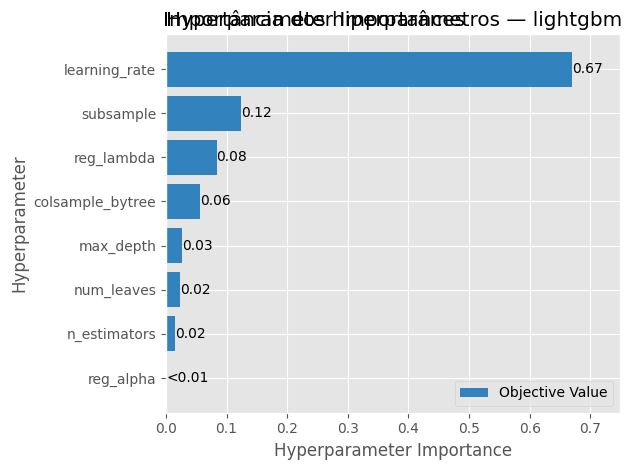

In [22]:
# Importância dos hiperparâmetros (modelo com menor RMSE na CV)
from optuna.visualization.matplotlib import plot_param_importances

melhor_estudo_nome = min(estudos_optuna, key=lambda k: estudos_optuna[k].best_value)
plot_param_importances(estudos_optuna[melhor_estudo_nome])
plt.title(f"Importância dos hiperparâmetros — {melhor_estudo_nome}")
plt.tight_layout()
plt.show()

In [23]:
# Mude para o número real de colunas do seu X_train

preprocessador_keras = Pipeline([
    ("preprocessador", criar_preprocessador()),
    ("scaler", StandardScaler()),
])
X_train_keras = preprocessador_keras.fit_transform(X_train)
X_test_keras = preprocessador_keras.transform(X_test)
X_val_keras = preprocessador_keras.transform(X_val)



y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_val_log = np.log1p(y_val)

INPUT_DIM = X_train_keras.shape[1]

# Configura o Tuner com Hyperband
tuner = kt.Hyperband(
    hypermodel=lambda hp: construir_modelo_otimizavel(hp, input_dim=INPUT_DIM),
    objective="val_mae",  # Vamos focar em minimizar o erro médio absoluto na validação
    max_epochs=50,        # Número máximo de épocas para os melhores modelos
    factor=3,             # Fator de descarte do Hyperband
    directory="diretorio_tuner",
    project_name="otimizacao_imoveis_mlp",
    overwrite=True        # Reseta as buscas anteriores ao rodar a célula
)

# Early stopping para não perder tempo se o modelo parar de melhorar
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Executa a busca (Passe seus arrays/tensores do Pandas aqui)
tuner.search(X_train_keras, y_train_log, epochs=20, 
             validation_data=(X_val_keras, y_val_log), 
             callbacks=[early_stop])

Trial 90 Complete [00h 00m 21s]
val_mae: 0.7925771474838257

Best val_mae So Far: 0.27427616715431213
Total elapsed time: 02h 14m 50s


In [28]:
PASTA_MODELOS = BASE_DIR / "models" / "joinville"
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)
melhores_hiperparametros_keras = tuner.get_best_hyperparameters(num_trials=1)[0]

print("--- MELHORES PARÂMETROS ENCONTRADOS ---")
print(f"Quantidade de camadas: {melhores_hiperparametros_keras.get('num_camadas')}")
print(f"Taxa de aprendizado (LR): {melhores_hiperparametros_keras.get('learning_rate')}")

# Mostra as unidades de cada camada que foi criada dinamicamente
for i in range(melhores_hiperparametros_keras.get('num_camadas')):
    print(f" -> Camada {i}: {melhores_hiperparametros_keras.get(f'unidades_{i}')} neurônios | Dropout: {melhores_hiperparametros_keras.get(f'dropout_{i}')}")


# 2. CONSTRUIR E SALVAR O MELHOR MODELO
# A documentação do Keras Tuner recomenda reconstruir o modelo com os melhores HPs
# e treiná-lo por completo (ou extrair direto os pesos já treinados)
melhor_modelo_keras = tuner.hypermodel.build(melhores_hiperparametros_keras)

# Se quiser pegar o modelo que já terminou o ciclo com os melhores pesos salvos no disco:
# melhor_modelo = tuner.get_best_models(num_models=1)[0]

# Cria a pasta de modelos caso ela não exista
import os
os.makedirs(PASTA_MODELOS, exist_ok=True)

# Salva o modelo no formato nativo atual do Keras (.keras)
caminho_modelo = PASTA_MODELOS / "mlp_preco_imoveis_log.keras"
melhor_modelo_keras.save(caminho_modelo)

print(f"\n✓ Modelo salvo com sucesso em: {caminho_modelo}")

--- MELHORES PARÂMETROS ENCONTRADOS ---
Quantidade de camadas: 4
Taxa de aprendizado (LR): 0.001
 -> Camada 0: 448 neurônios | Dropout: 0.4
 -> Camada 1: 512 neurônios | Dropout: 0.0
 -> Camada 2: 320 neurônios | Dropout: 0.4
 -> Camada 3: 192 neurônios | Dropout: 0.30000000000000004

✓ Modelo salvo com sucesso em: c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\models\joinville\mlp_preco_imoveis_log.keras


## Treino e avaliação (hiperparâmetros otimizados)

Modelos treinados com os melhores hiperparâmetros encontrados pelo Optuna (seção anterior):
- **Regressão linear** (baseline, sem tuning)
- **Random Forest**, **HistGradientBoosting**, **LightGBM**, **CatBoost**
- **Rede neural** (Keras MLP)

In [29]:
def criar_estimador_otimizado(nome):
    p = melhores_hiperparametros_modelos[nome]
    if nome == "catboost":
        return CatBoostRegressor(
            **p,
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=0,
        )
    if nome == "lightgbm":
        return LGBMRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    if nome == "random_forest":
        return RandomForestRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1)
    if nome == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(**p, random_state=RANDOM_STATE)
    raise ValueError(nome)


modelos_sklearn = {
    "linear_regression": LinearRegression(),
    **{nome: criar_estimador_otimizado(nome) for nome in melhores_hiperparametros_modelos},
}

resultados = {}
pipelines = {}

print("=== Treino final com hiperparâmetros otimizados (Optuna) ===")
for nome, estimador in modelos_sklearn.items():
    pipelines[nome], resultados[nome] = treinar_pipeline(
        nome, estimador, X_train, y_train, X_test, y_test
    )

=== Treino final com hiperparâmetros otimizados (Optuna) ===
linear_regression: RMSE=R$ 2,465 | MAE=R$ 1,617 | MAPE=46.1% | R²=0.499
catboost: RMSE=R$ 2,361 | MAE=R$ 1,567 | MAPE=47.8% | R²=0.540
lightgbm: RMSE=R$ 2,299 | MAE=R$ 1,456 | MAPE=48.0% | R²=0.564
random_forest: RMSE=R$ 2,205 | MAE=R$ 1,406 | MAPE=42.2% | R²=0.599
hist_gradient_boosting: RMSE=R$ 2,319 | MAE=R$ 1,507 | MAPE=49.9% | R²=0.556


In [31]:
print("\n=== Rede neural (Keras MLP) ===")

preprocessador_keras = Pipeline([
    ("preprocessador", criar_preprocessador()),
    ("scaler", StandardScaler()),
])
X_train_keras = preprocessador_keras.fit_transform(X_train)
X_test_keras = preprocessador_keras.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

mlp = criar_mlp(X_train_keras.shape[1])
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
mlp.fit(
    X_train_keras,
    y_train_log,
    validation_split=0.15,
    epochs=1000,
    batch_size=256,
    callbacks=[early_stop],
    verbose=0,
)

pred_keras = np.expm1(mlp.predict(X_test_keras, verbose=0).ravel())

resultados["keras_mlp"] = metricas("keras_mlp", y_test, pred_keras)

pred_keras_melhor = np.expm1(melhor_modelo_keras.predict(X_test_keras, verbose=0).ravel())

resultados["keras_mlp_melhor"] = metricas("keras_mlp_melhor", y_test, pred_keras_melhor)


=== Rede neural (Keras MLP) ===
keras_mlp: RMSE=R$ 384,610,435,314 | MAE=R$ 7,461,490,987 | MAPE=63309648.2% | R²=-12195532215720484.000
keras_mlp_melhor: RMSE=R$ 7,440 | MAE=R$ 6,574 | MAPE=100.0% | R²=-3.563


In [32]:
df_resultados = (
    pd.DataFrame(resultados)
    .T.sort_values("rmse")
    .assign(
        rmse=lambda d: d["rmse"].map(lambda x: f"R$ {x:,.0f}"),
        mae=lambda d: d["mae"].map(lambda x: f"R$ {x:,.0f}"),
        mape=lambda d: d["mape"].map(lambda x: f"{x:.1f}%"),
        r2=lambda d: d["r2"].map(lambda x: f"{x:.3f}"),
    )
)
df_resultados

melhor_modelo = min(resultados, key=lambda k: resultados[k]["rmse"])
if melhor_modelo == "keras_mlp":
    pipeline_final = preprocessador_keras
    modelo_final_keras = mlp
else:
    pipeline_final = pipelines[melhor_modelo]
    modelo_final_keras = None

print(f"\nModelo selecionado: {melhor_modelo}")


Modelo selecionado: random_forest


In [33]:
df_resultados

,rmse,mae,mape,r2
random_forest,"R$ 2,205","R$ 1,406",42.2%,0.599
lightgbm,"R$ 2,299","R$ 1,456",48.0%,0.564
hist_gradient_boosting,"R$ 2,319","R$ 1,507",49.9%,0.556
catboost,"R$ 2,361","R$ 1,567",47.8%,0.540
linear_regression,"R$ 2,465","R$ 1,617",46.1%,0.499
keras_mlp_melhor,"R$ 7,440","R$ 6,574",100.0%,-3.563
keras_mlp,"R$ 384,610,435,314","R$ 7,461,490,987",63309648.2%,-12195532215720484.000


## Persistência do modelo

In [34]:
PASTA_MODELOS = BASE_DIR / "models" / "joinville"
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

caminho_metadata = PASTA_MODELOS / "metadata.json"

metadata = {
    "cidade": cidade,
    "estado": estado,
    "arquivo_dados": "joinville_com_ind_local_2026-05.parquet",
    "target": TARGET,
    "features_numericas": NUMERIC_FEATURES,
    "features_categoricas": CATEGORICAL_FEATURES,
    "colunas_excluidas_leakage": COLUNAS_LEAKAGE,
    "modelo_selecionado": melhor_modelo,
    "hiperparametros_optuna": melhores_hiperparametros_modelos,
    "rmse_cv_optuna": {k: estudos_optuna[k].best_value for k in estudos_optuna},
    "metricas_todos_modelos": resultados,
    "metricas_teste": resultados[melhor_modelo],
    "n_treino": int(len(X_train)),
    "n_teste": int(len(X_test)),
}

if melhor_modelo == "keras_mlp":
    caminho_pipeline = PASTA_MODELOS / "preprocessador_keras.pkl"
    caminho_keras = PASTA_MODELOS / "keras_mlp_preco_imoveis.keras"
    joblib.dump(pipeline_final, caminho_pipeline)
    modelo_final_keras.save(caminho_keras)
    metadata["arquivos_modelo"] = [str(caminho_pipeline), str(caminho_keras)]
    print(f"Preprocessador Keras: {caminho_pipeline}")
    print(f"Rede neural Keras: {caminho_keras}")
else:
    caminho_pipeline = PASTA_MODELOS / "pipeline_preco_imoveis.pkl"
    joblib.dump(pipeline_final, caminho_pipeline)
    metadata["arquivos_modelo"] = [str(caminho_pipeline)]
    print(f"Pipeline salvo em: {caminho_pipeline}")

with open(caminho_metadata, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=float)

print(f"Metadados em: {caminho_metadata}")

Pipeline salvo em: c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\models\joinville\pipeline_preco_imoveis.pkl
Metadados em: c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\models\joinville\metadata.json


## Importância das features (SHAP)

Análise de interpretabilidade com [SHAP](https://shap.readthedocs.io/): impacto de cada variável na predição de `valor_imovel`.

Usa o melhor modelo em árvore/boosting disponível (ou o modelo vencedor, se for sklearn).

In [162]:
MODELOS_TREE = {"random_forest", "hist_gradient_boosting", "lightgbm", "catboost"}
N_BACKGROUND = 300
N_EXPLAIN = 500

if melhor_modelo in pipelines:
    modelo_shap_nome = melhor_modelo
elif melhor_modelo == "keras_mlp":
    modelo_shap_nome = min(
        (k for k in resultados if k in MODELOS_TREE),
        key=lambda k: resultados[k]["rmse"],
    )
else:
    modelo_shap_nome = "catboost"

print(f"Modelo explicado com SHAP: {modelo_shap_nome}")

pipe_shap = pipelines[modelo_shap_nome]
preprocessador_shap = pipe_shap.named_steps["preprocessador"]
modelo_shap = pipe_shap.named_steps["modelo"]

idx_bg = X_train.sample(N_BACKGROUND, random_state=42).index
idx_ex = X_test.sample(min(N_EXPLAIN, len(X_test)), random_state=42).index

X_bg_shap = preprocessador_shap.transform(X_train.loc[idx_bg])
X_ex_shap = preprocessador_shap.transform(X_test.loc[idx_ex])
nomes_features_shap = preprocessador_shap.get_feature_names_out()

if modelo_shap_nome in MODELOS_TREE:
    explainer_shap = shap.TreeExplainer(modelo_shap, data=X_bg_shap)
    shap_values = explainer_shap.shap_values(X_ex_shap)
elif modelo_shap_nome == "linear_regression":
    explainer_shap = shap.LinearExplainer(modelo_shap, X_bg_shap)
    shap_values = explainer_shap.shap_values(X_ex_shap)
else:
    explainer_shap = shap.Explainer(modelo_shap.predict, X_bg_shap)
    shap_values = explainer_shap(X_ex_shap).values

if isinstance(shap_values, list):
    shap_values = shap_values[0]

importancia_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=nomes_features_shap,
).sort_values(ascending=False)

importancia_shap.head(20)

Modelo explicado com SHAP: random_forest


 95%|=================== | 475/500 [00:17<00:00]       

cat__tipo_imovel_apartamento      535.188035
cat__tipo_imovel_casa             447.094829
num__quartos                      283.626863
num__banheiros                    248.790227
cat__bairro_america               242.687939
cat__tipo_imovel_terreno          209.807801
num__vagas                        178.496834
num__score                        169.270235
cat__bairro_atiradores            124.368405
cat__bairro_gloria                 97.795824
cat__bairro_anita garibaldi        78.825908
cat__bairro_centro                 66.573901
cat__bairro_infrequent_sklearn     56.484093
cat__bairro_floresta               47.870260
cat__bairro_santo antonio          45.550812
cat__bairro_paranaguamirim         43.094237
cat__bairro_saguacu                34.201855
cat__tipo_imovel_rural             30.356112
cat__bairro_costa e silva          23.620743
cat__bairro_joao costa             19.254724
dtype: float64

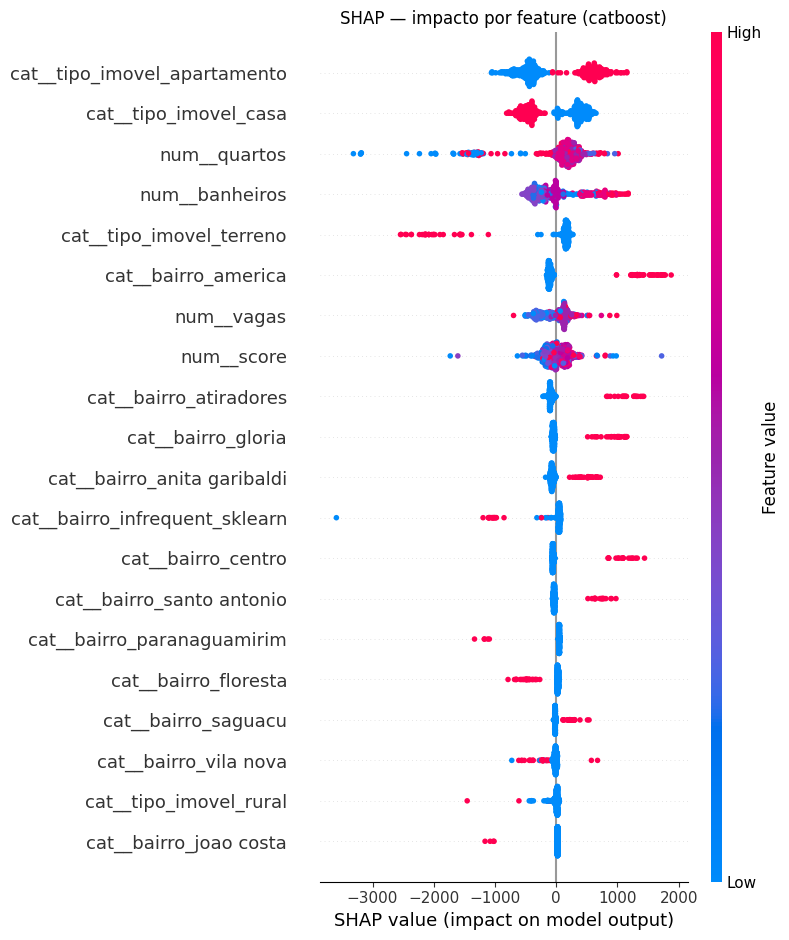

In [100]:
shap.summary_plot(
    shap_values,
    X_ex_shap,
    feature_names=nomes_features_shap,
    show=False,
    max_display=20,
)
plt.title(f"SHAP — impacto por feature ({modelo_shap_nome})")
plt.tight_layout()
plt.show()

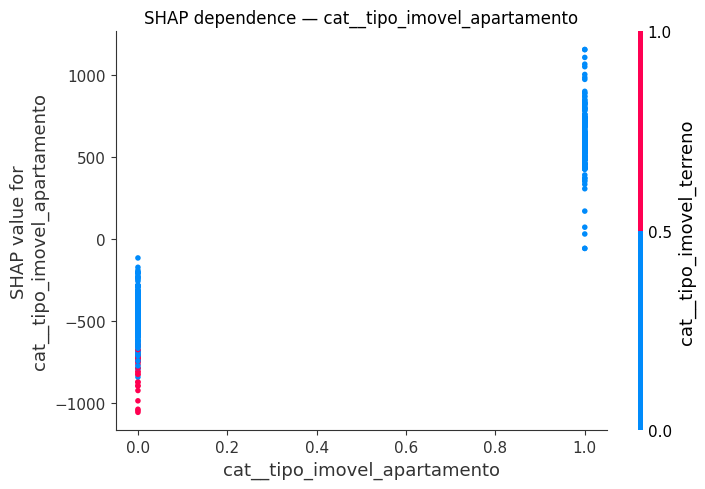

In [101]:
# Gráfico de dependência da feature mais importante
feature_top = importancia_shap.index[0]
shap.dependence_plot(
    feature_top,
    shap_values,
    X_ex_shap,
    feature_names=nomes_features_shap,
    show=False,
)
plt.title(f"SHAP dependence — {feature_top}")
plt.tight_layout()
plt.show()

## Exemplos de previsão no conjunto de teste

In [48]:
if melhor_modelo == "keras_mlp":
    pred_test = np.expm1(modelo_final_keras.predict(pipeline_final.transform(X_test), verbose=0).ravel())
else:
    pred_test = pipeline_final.predict(X_test)

exemplos = df_modelo.loc[X_test.index, [
    "bairro", 
    "tipo_imovel", 
    "metragem", 
    "quartos",
    "url",
    "score",
    f"{TARGET}", 
]].copy()
exemplos["preco_previsto"] = pred_test.round(0).astype(int)
exemplos["erro_abs"] = (exemplos[f"{TARGET}"] - exemplos["preco_previsto"]).abs()
exemplos["erro_pct"] = (exemplos["erro_abs"] / exemplos[f"{TARGET}"] * 100).round(1)

exemplos.sort_values("erro_pct").tail(200)

,bairro,tipo_imovel,metragem,quartos,url,score,preco_por_m2,preco_previsto,erro_abs,erro_pct
23186,pirabeiraba,outros,200.0,3,https://sc.olx.com.br/norte-de-santa-catarina/...,15.39,3300.000000,5945,2645.000000,80.2
6173,anita garibaldi,terreno,977.0,0,https://www.chavesnamao.com.br/imovel/terreno-...,33.04,1187.308086,2143,955.691914,80.5
6600,santo antonio,terreno,1172.0,0,https://www.chavesnamao.com.br/imovel/terreno-...,32.49,938.566553,1697,758.433447,80.8
9213,vila nova,casa,260.0,3,https://www.chavesnamao.com.br/imovel/casa-a-v...,11.77,3653.846154,6610,2956.153846,80.9
7834,boa vista,outros,300.0,0,https://www.chavesnamao.com.br/imovel/ponto-co...,27.88,2833.333333,5130,2296.666667,81.1
...,...,...,...,...,...,...,...,...,...,...
25593,pirabeiraba,casa,60.0,1,https://sc.olx.com.br/norte-de-santa-catarina/...,15.37,233.333333,4559,4325.666667,1853.9
2021,pirabeiraba,rural,5000.0,4,https://www.vivareal.com.br/imovel/fazenda---s...,0.76,210.000000,4425,4215.000000,2007.1
6602,distrito industrial,terreno,16710.0,3,https://www.chavesnamao.com.br/imovel/terreno-...,11.42,329.144225,7353,7023.855775,2134.0
2172,anita garibaldi,apartamento,5000.0,4,https://www.vivareal.com.br/imovel/apartamento...,55.04,458.000000,11604,11146.000000,2433.6


In [73]:
exemplos[exemplos['erro_pct'] <= 60].sort_values("erro_pct").tail(50)

,bairro,tipo_imovel,metragem,quartos,url,score,preco_por_m2,preco_previsto,erro_abs,erro_pct
13863,espinheiros,terreno,200.0,0,https://www.chavesnamao.com.br/imovel/terreno-...,22.91,1600.000000,2455,855.000000,53.4
5635,floresta,terreno,3047.0,0,https://www.chavesnamao.com.br/imovel/terreno-...,55.01,879.553659,1349,469.446341,53.4
22111,gloria,apartamento,101.0,3,https://sc.olx.com.br/norte-de-santa-catarina/...,22.72,5138.613861,7886,2747.386139,53.5
285,comasa,terreno,450.0,0,https://www.zapimoveis.com.br/imovel/venda-ter...,18.56,1866.666667,861,1005.666667,53.9
7453,costa e silva,apartamento,66.0,1,https://www.chavesnamao.com.br/imovel/apartame...,15.93,4242.424242,6529,2286.575758,53.9
15097,anita garibaldi,apartamento,106.0,3,https://www.chavesnamao.com.br/imovel/apartame...,33.04,5188.679245,8002,2813.320755,54.2
22990,jarivatuba,casa,109.0,3,https://sc.olx.com.br/norte-de-santa-catarina/...,28.08,2614.678899,4037,1422.321101,54.4
10318,petropolis,casa,150.0,2,https://www.chavesnamao.com.br/imovel/casa-a-v...,34.65,3332.666667,5152,1819.333333,54.6
8251,america,apartamento,292.0,3,https://www.chavesnamao.com.br/imovel/apartame...,34.82,27397.260274,12371,15026.260274,54.8
3372,vila nova,casa,130.0,3,https://www.chavesnamao.com.br/imovel/casa-a-v...,22.51,3230.769231,5000,1769.230769,54.8


In [74]:
exemplos[exemplos['erro_pct'] <= 60].sort_values("erro_pct").tail(50)["url"].tolist()

['https://www.chavesnamao.com.br/imovel/terreno-em-condominio-a-venda-sc-joinville-espinheiros-200m2-RS320000/id-34871877/',
 'https://www.chavesnamao.com.br/imovel/terreno-a-venda-sc-joinville-floresta-3047m2-RS2680000/id-27666227/',
 'https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-joinville-gloria-1493121825',
 'https://www.zapimoveis.com.br/imovel/venda-terreno-lote-comercial-comasa-joinville-450m2-id-2882639793/?source=ranking%2Crp',
 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-1-quarto-com-garagem-sc-joinville-costa-e-silva-66m2-RS280000/id-29564287/',
 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-3-quartos-com-garagem-sc-joinville-anita-garibaldi-144m2-RS550000/id-35817639/',
 'https://sc.olx.com.br/norte-de-santa-catarina/imoveis/casa-joinville-jarivatuba-quartos-3-1491014299',
 'https://www.chavesnamao.com.br/imovel/casa-a-venda-2-quartos-com-garagem-sc-joinville-petropolis-384m2-RS499900/id-28082286/',
 'https://www.chavesnamao.c

<Axes: title={'center': 'preco_previsto médio por bairro'}, ylabel='bairro,tipo_imovel'>

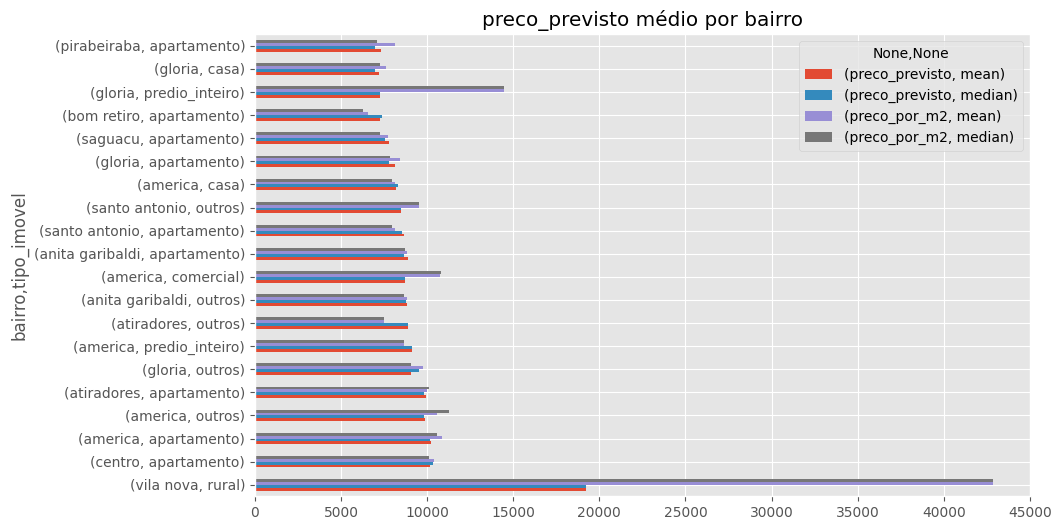

In [36]:
grouped_preco_previsto_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"preco_previsto": [
                                                                                            "mean", 
                                                                                           "median"
                                                                                           ],
                                                                        "preco_por_m2": [
                                                                            "mean", 
                                                                            "median"]})#.sort_values("erro_pct", ascending=False)

grouped_preco_previsto_bairro.sort_values(("preco_previsto", "median"), ascending=False).head(20).plot(kind="barh", figsize=(10, 6), title="preco_previsto médio por bairro")

<Axes: title={'center': 'Erro percentual médio por bairro'}, ylabel='bairro,tipo_imovel'>

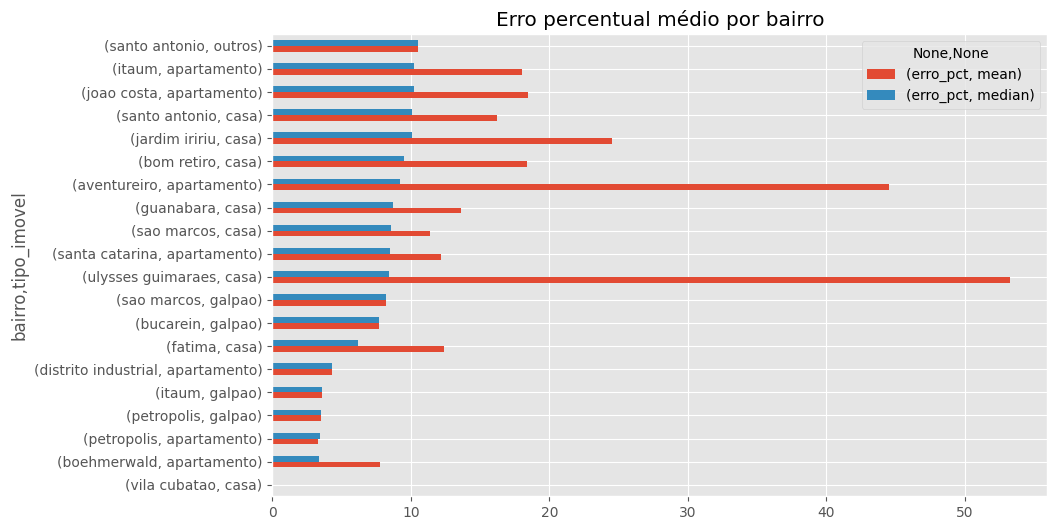

In [37]:
grouped_erro_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"erro_pct": ["mean", "median"]})#.sort_values("erro_pct", ascending=False)

grouped_erro_bairro.sort_values(("erro_pct", "median"), ascending=True).head(20).plot(kind="barh", figsize=(10, 6), title="Erro percentual médio por bairro")

In [38]:
bairros = df_modelo["bairro"].unique()
tipos = df_modelo["tipo_imovel"].unique()

metrics_bairro = {}

for bairro in bairros:
    for tipo in tipos:
        try:
            print(f"{bairro} - {tipo} - Métricas por bairro:")
            previsao_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"preco_previsto"]
            valor_verdadeiro_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"{TARGET}"]
            metrics_bairro[(bairro, tipo)] = metricas(bairro, valor_verdadeiro_bairro, previsao_bairro)
        except Exception as e:
            print(f"Erro ao processar o bairro {bairro}: {e}")
    

joao costa - apartamento - Métricas por bairro:
joao costa: RMSE=R$ 995 | MAE=R$ 785 | MAPE=18.5% | R²=0.000
joao costa - comercial - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - casa - Métricas por bairro:
joao costa: RMSE=R$ 1,642 | MAE=R$ 1,323 | MAPE=46.0% | R²=-0.193
joao costa - outros - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - terreno - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - rural - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - galpao - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is r

In [39]:
metrics_bairro_df = pd.DataFrame(metrics_bairro).T.sort_values("mape", ascending=True)
metrics_bairro_df.head(40)

rmse          mae       mape  \
vila cubatao        casa            2.000000     2.000000   0.050000   
petropolis          apartamento   217.994686   197.224731   3.306896   
                    galpao        149.031746   149.031746   3.503358   
itaum               galpao        155.173913   155.173913   3.569000   
distrito industrial apartamento   232.733333   232.733333   4.349126   
bucarein            galpao        465.217391   465.217391   7.670251   
boehmerwald         apartamento   615.090160   410.287020   7.800517   
sao marcos          galpao        359.000000   359.000000   8.205714   
santo antonio       outros       1350.490265  1037.072909  10.500491   
anita garibaldi     outros       1066.736821   980.970522  11.064600   
sao marcos          casa         1024.964833   733.885696  11.382800   
nova brasilia       apartamento   754.514668   611.135642  11.696719   
santa catarina      apartamento   723.802963   652.335224  12.185141   
iririu              galpao        482.207921   482.207921  12.298737   
fatima              casa          932.535267   613.527428  12.411797   
pirabeiraba         apartamento  2476.215312  1378.833469  12.833370   
jardim iririu       apartamento   841.632242   665.027840  12.947928   
jardim sofia        casa         1118.773601   867.457394  13.524009   
guanabara           casa          954.868322   673.781918  13.619917   
iririu              apartamento  1044.993406   802.232224  14.021615   
nova brasilia       galpao        661.428571   661.428571  14.468750   
guanabara           apartamento  1038.027509   880.002869  14.744041   
saguacu             casa         1384.254671   957.583694  15.520902   
santa catarina      casa         1679.130303  1084.702265  16.041282   
santo antonio       casa         2218.017558  1314.260358  16.212121   
profipo             casa          700.333333   700.333333  16.841683   
itinga              apartamento   763.196078   763.196078  16.923043   
vila nova           apartamento  1156.827360   937.118500  17.382835   
jarivatuba          apartamento  1008.891021   903.791712  17.546935   
atiradores          casa         1404.669926  1262.779960  17.692431   
itaum               apartamento  1194.435005   896.639278  18.010131   
costa e silva       apartamento  1436.670553  1105.954122  18.088971   
bom retiro          casa         2044.964292  1033.300669  18.409978   
joao costa          apartamento   994.782945   785.306938  18.474325   
saguacu             apartamento  1640.902628  1290.342459  18.686649   
atiradores          outros       1633.971472  1411.360902  18.795776   
boa vista           apartamento   968.920874   770.183953  19.474049   
america             outros       2103.362102  1889.930443  19.990701   
bucarein            casa         1656.388359  1136.319057  20.361089   
america             apartamento  3041.383777  2124.653159  20.909474   

                                           r2  
vila cubatao        casa                  NaN  
petropolis          apartamento      0.896133  
                    galpao                NaN  
itaum               galpao                NaN  
distrito industrial apartamento           NaN  
bucarein            galpao                NaN  
boehmerwald         apartamento     -0.589817  
sao marcos          galpao                NaN  
santo antonio       outros          -7.944990  
anita garibaldi     outros          -0.000857  
sao marcos          casa             0.151510  
nova brasilia       apartamento     -0.380644  
santa catarina      apartamento      0.425639  
iririu              galpao                NaN  
fatima              casa            -0.459825  
pirabeiraba         apartamento      0.506289  
jardim iririu       apartamento     -0.194965  
jardim sofia        casa            -0.057015  
guanabara           casa             0.126794  
iririu              apartamento      0.234288  
nova brasilia       galpao                NaN  
guanabara           apartamento